<a href="https://colab.research.google.com/github/ShrutiPatel263/AeroCare/blob/main/State_Of_the_Art_Model_FD002.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


# Pre-processing

In [ ]:
import numpy as np
import pandas as pd

from IPython.display import display, HTML
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.io as pio


import seaborn as sns
from importlib import reload
import matplotlib.pyplot as plt
import matplotlib
import warnings

# Configure Jupyter Notebook
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 500)
pd.set_option('display.expand_frame_repr', False)
# pd.set_option('max_colwidth', -1)
display(HTML("<style>div.output_scroll { height: 35em; }</style>"))

reload(plt)
%matplotlib inline
%config InlineBackend.figure_format ='retina'

warnings.filterwarnings('ignore')

# configure plotly graph objects
pio.renderers.default = 'iframe'
# pio.renderers.default = 'vscode'

pio.templates["ck_template"] = go.layout.Template(
    layout_colorway = px.colors.sequential.Viridis,
#     layout_hovermode = 'closest',
#     layout_hoverdistance = -1,
    layout_autosize=False,
    layout_width=800,
    layout_height=600,
    layout_font = dict(family="Calibri Light"),
    layout_title_font = dict(family="Calibri"),
    layout_hoverlabel_font = dict(family="Calibri Light"),
#     plot_bgcolor="white",
)

# pio.templates.default = 'seaborn+ck_template+gridon'
pio.templates.default = 'ck_template+gridon'
# pio.templates.default = 'seaborn+gridon'
# pio.templates

In [ ]:
index_names = ['engine', 'cycle']
setting_names = ['setting_1', 'setting_2', 'setting_3']
sensor_names=[ "(Fan inlet temperature) (◦R)",
"(LPC outlet temperature) (◦R)",
"(HPC outlet temperature) (◦R)",
"(LPT outlet temperature) (◦R)",
"(Fan inlet Pressure) (psia)",
"(bypass-duct pressure) (psia)",
"(HPC outlet pressure) (psia)",
"(Physical fan speed) (rpm)",
"(Physical core speed) (rpm)",
"(Engine pressure ratio(P50/P2)",
"(HPC outlet Static pressure) (psia)",
"(Ratio of fuel flow to Ps30) (pps/psia)",
"(Corrected fan speed) (rpm)",
"(Corrected core speed) (rpm)",
"(Bypass Ratio) ",
"(Burner fuel-air ratio)",
"(Bleed Enthalpy)",
"(Required fan speed)",
"(Required fan conversion speed)",
"(High-pressure turbines Cool air flow)",
"(Low-pressure turbines Cool air flow)" ]
col_names = index_names + setting_names + sensor_names

In [ ]:
df_train = pd.read_csv('/content/drive/MyDrive/CMaps-20260216T121855Z-1-001/CMaps/train_FD002.txt',sep=r'\s+',header=None,index_col=False,names=col_names)
df_test = pd.read_csv('/content/drive/MyDrive/CMaps-20260216T121855Z-1-001/CMaps/test_FD002.txt',sep=r'\s+',header=None,index_col=False,names=col_names)
df_test_RUL = pd.read_csv('/content/drive/MyDrive/CMaps-20260216T121855Z-1-001/CMaps/RUL_FD002.txt',sep=r'\s+',header=None,index_col=False,names=['RUL'])

In [ ]:
import os
# List contents of the specific folder to find the datasets
target_path = '/content/drive/MyDrive/CMaps-20260216T121855Z-1-001'
if os.path.exists(target_path):
    print(f"Contents of {target_path}:")
    print(os.listdir(target_path))
else:
    print(f"Folder not found at {target_path}")

Contents of /content/drive/MyDrive/CMaps-20260216T121855Z-1-001:
['CMaps']


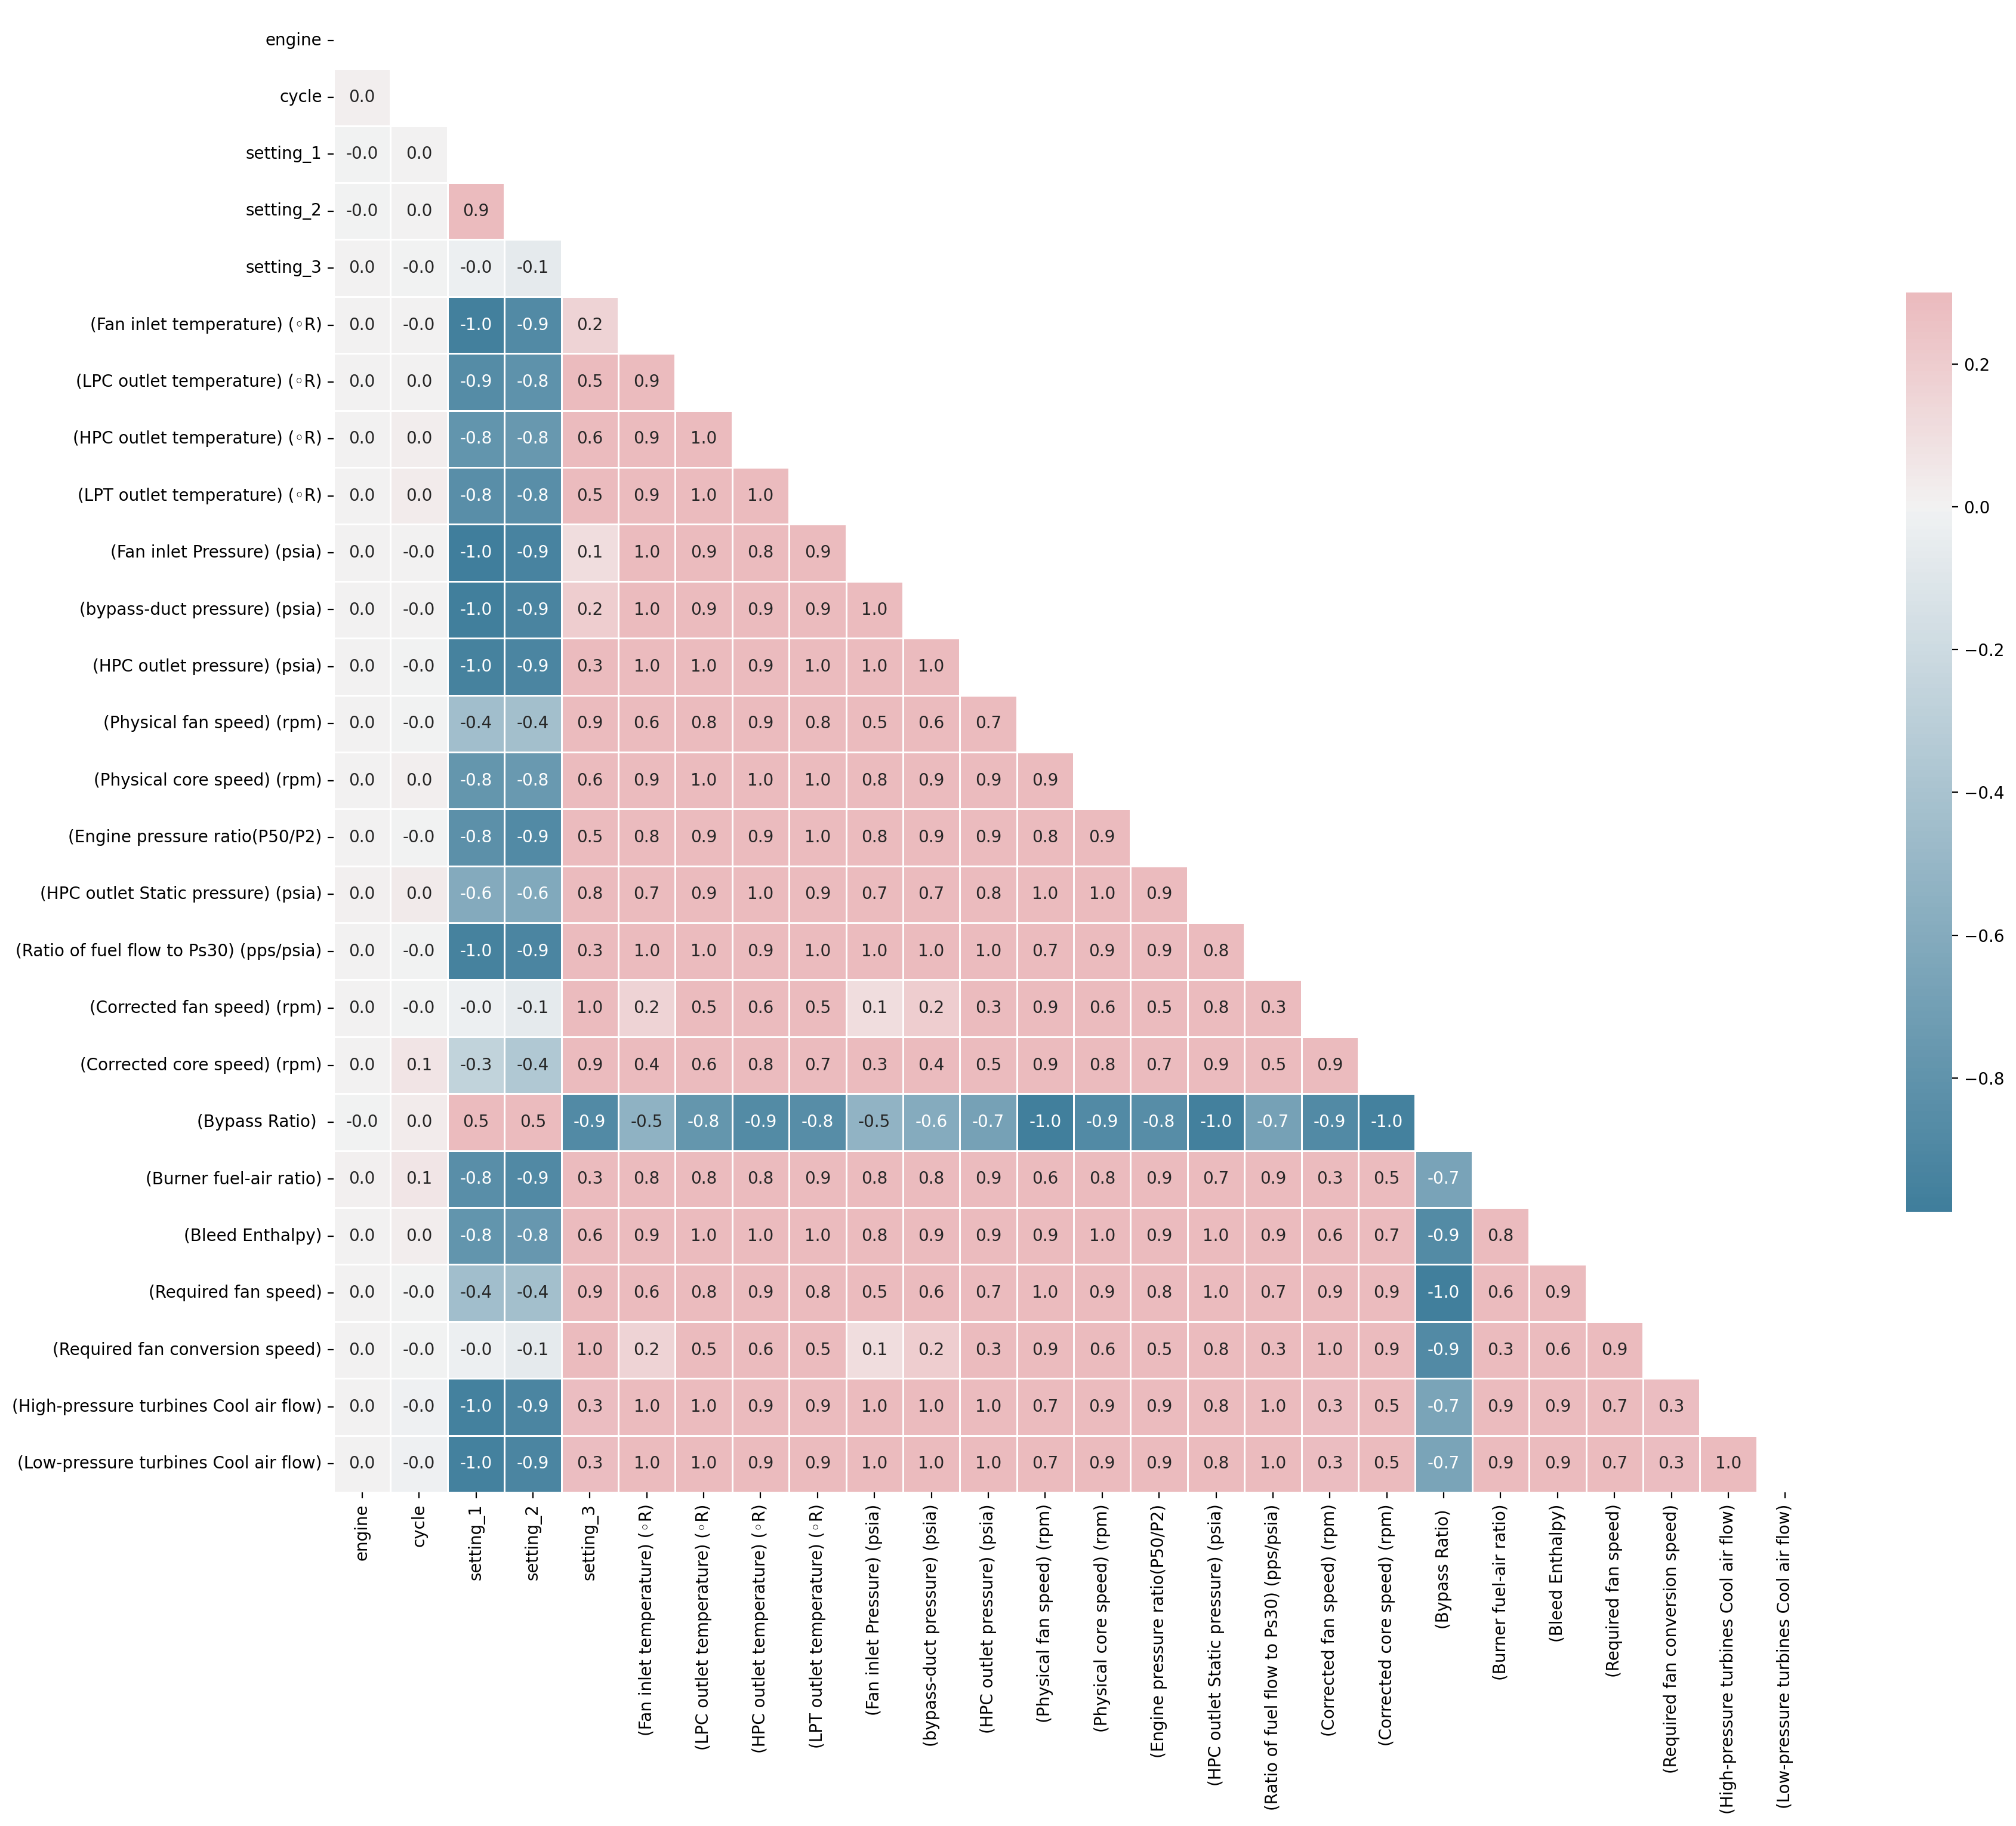

In [ ]:

corr = df_train.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

f, ax = plt.subplots(figsize=(20, 20))
cmap = sns.diverging_palette(230, 10, as_cmap=True)

# Draw the heatmap with annotation
sns.heatmap(
    corr,
    mask=mask,
    cmap=cmap,
    vmax=.3,
    center=0,
    square=True,
    linewidths=.5,
    cbar_kws={"shrink": .5},
    annot=True,           # <- Add this line
    fmt=".1f"             # <- Format the numbers to 2 decimal places
)

plt.show()


In [ ]:
sens_const_values = []
for feature in list(setting_names + sensor_names):
    try:
        if df_train[feature].min()==df_train[feature].max():
            sens_const_values.append(feature)
    except:
        pass

print(sens_const_values)
df_train.drop(sens_const_values,axis=1,inplace=True)
df_test.drop(sens_const_values,axis=1,inplace=True)

[]


In [ ]:
cor_matrix = df_train.corr().abs()
upper_tri = cor_matrix.where(np.triu(np.ones(cor_matrix.shape),k=1).astype(np.bool))
corr_features = [column for column in upper_tri.columns if any(upper_tri[column] > 0.95)]
print(corr_features)
df_train.drop(corr_features,axis=1,inplace=True)
df_test.drop(corr_features,axis=1,inplace=True)

['(Fan inlet temperature) (◦R)', '(HPC outlet temperature) (◦R)', '(LPT outlet temperature) (◦R)', '(Fan inlet Pressure) (psia)', '(bypass-duct pressure) (psia)', '(HPC outlet pressure) (psia)', '(Physical core speed) (rpm)', '(Engine pressure ratio(P50/P2)', '(HPC outlet Static pressure) (psia)', '(Ratio of fuel flow to Ps30) (pps/psia)', '(Corrected fan speed) (rpm)', '(Bypass Ratio) ', '(Bleed Enthalpy)', '(Required fan speed)', '(Required fan conversion speed)', '(High-pressure turbines Cool air flow)', '(Low-pressure turbines Cool air flow)']


In [ ]:
features = list(df_train.columns)

In [ ]:
# check for missing data
for feature in features:
    print(feature + " - " + str(len(df_train[df_train[feature].isna()])))

engine - 0
cycle - 0
setting_1 - 0
setting_2 - 0
setting_3 - 0
(LPC outlet temperature) (◦R) - 0
(Physical fan speed) (rpm) - 0
(Corrected core speed) (rpm) - 0
(Burner fuel-air ratio) - 0


In [ ]:
# define the maximum life of each engine, as this could be used to obtain the RUL at each point in time of the engine's life
df_train_RUL = df_train.groupby(['engine']).agg({'cycle':'max'})
df_train_RUL.rename(columns={'cycle':'life'},inplace=True)
df_train_RUL.head()

,life
engine,
1,149
2,269
3,206
4,235
5,154


In [ ]:
df_train=df_train.merge(df_train_RUL,how='left',on=['engine'])

In [ ]:
df_train['RUL']=df_train['life']-df_train['cycle']
df_train.drop(['life'],axis=1,inplace=True)

# the RUL prediction is only useful nearer to the end of the engine's life, therefore we put an upper limit on the RUL
# this is a bit sneaky, since it supposes that the test set has RULs of less than this value, the closer you are
# to the true value, the more accurate the model will be
df_train['RUL'][df_train['RUL']>125]=125
df_train.head()

,engine,cycle,setting_1,setting_2,setting_3,(LPC outlet temperature) (◦R),(Physical fan speed) (rpm),(Corrected core speed) (rpm),(Burner fuel-air ratio),RUL
0,1,1,34.9983,0.8400,100.0,555.32,2222.65,8048.56,0.02,125
1,1,2,41.9982,0.8408,100.0,549.90,2211.57,8072.30,0.02,125
2,1,3,24.9988,0.6218,60.0,537.31,1915.11,7864.87,0.02,125
3,1,4,42.0077,0.8416,100.0,549.51,2211.58,8068.66,0.02,125
4,1,5,25.0005,0.6203,60.0,537.07,1915.10,7861.23,0.02,125


In [ ]:
def create_sequences(df, window_size, stride, engine_col='engine'):
    sequences, targets, engine_ids = [], [], []

    for engine_id in df[engine_col].unique():
        engine_data = df[df[engine_col] == engine_id].sort_values('cycle')
        feature_cols = [col for col in engine_data.columns if col not in ['engine', 'cycle', 'RUL']]

        values = engine_data[feature_cols].values
        rul_values = engine_data['RUL'].values

        for i in range(0, len(values) - window_size + 1, stride):
            sequences.append(values[i:i + window_size])
            targets.append(rul_values[i + window_size - 1])
            engine_ids.append(engine_id)

    return np.array(sequences), np.array(targets), np.array(engine_ids)

# Scale features
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
feature_cols = [col for col in df_train.columns if col not in ['engine', 'cycle', 'RUL']]
df_train[feature_cols] = scaler.fit_transform(df_train[feature_cols])
df_test[feature_cols] = scaler.transform(df_test[feature_cols])

In [ ]:
!pip install tensorflow

In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GroupKFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, regularizers
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [ ]:
np.random.seed(42)
tf.random.set_seed(42)

In [ ]:
# ============================================================
# ADVANCED RUL PREDICTION: Gated Ensemble BiLSTM + Attention (Optimized)
# ============================================================

import tensorflow as tf
from tensorflow.keras import layers, models, regularizers, callbacks, optimizers
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# MODIFIED create_sequences function to handle missing 'RUL' column for test set
def create_sequences(df, window_size, stride, engine_col='engine'):
    sequences, targets, engine_ids = [], [], []

    # Check if 'RUL' column exists in the DataFrame
    has_rul = 'RUL' in df.columns

    for engine_id in df[engine_col].unique():
        engine_data = df[df[engine_col] == engine_id].sort_values('cycle')
        feature_cols = [col for col in engine_data.columns if col not in ['engine', 'cycle', 'RUL']]

        values = engine_data[feature_cols].values

        if has_rul:
            rul_values = engine_data['RUL'].values
        else:
            # If RUL column is not present (e.g., for test data), create a dummy array.
            # These 'targets' will be discarded for X_test anyway.
            rul_values = np.array([])

        # Ensure there are enough data points for the window
        if len(values) < window_size:
            continue # Skip engines that are too short for a single sequence

        for i in range(0, len(values) - window_size + 1, stride):
            sequences.append(values[i:i + window_size])
            if has_rul: # Only append RUL target if RUL column exists
                targets.append(rul_values[i + window_size - 1])
            engine_ids.append(engine_id)

    return np.array(sequences), np.array(targets), np.array(engine_ids)


CONFIG = {
    'WINDOW_SIZE': 30,
    'STRIDE': 2,
    'LSTM_UNITS': [128, 64],
    'DENSE_UNITS': 80,
    'DROPOUT_RATE': 0.5,
    'L2_REG': 0.03,
    'BATCH_SIZE': 64,
    'EPOCHS': 200,
    'LEARNING_RATE': 0.001,
    'PATIENCE': 30,
    'N_SPLITS': 5
}

print("\nOptimized Configuration:")
for k, v in CONFIG.items():
    print(f"  {k}: {v}")


X_train, y_train, train_engine_ids = create_sequences(
    df_train, CONFIG['WINDOW_SIZE'], CONFIG['STRIDE']
)
X_test, _, test_engine_ids = create_sequences(
    df_test, CONFIG['WINDOW_SIZE'], CONFIG['STRIDE']
)

print(f"Training sequences: {X_train.shape}")
print(f"Test sequences: {X_test.shape}")


# ============================================================
# Custom Layers
# ============================================================

class GatingLayer(layers.Layer):
    def __init__(self, num_branches, **kwargs):
        super(GatingLayer, self).__init__(**kwargs)
        self.num_branches = num_branches

    def build(self, input_shape):
        self.gate_weights = self.add_weight(
            shape=(input_shape[0][-1], self.num_branches),
            initializer='glorot_uniform',
            trainable=True
        )
        self.gate_bias = self.add_weight(
            shape=(self.num_branches,),
            initializer='zeros',
            trainable=True
        )

    def call(self, inputs):
        input_stats = tf.reduce_mean(inputs[0], axis=1)
        gate_scores = tf.nn.softmax(tf.matmul(input_stats, self.gate_weights) + self.gate_bias, axis=-1)
        gate_scores = tf.expand_dims(tf.expand_dims(gate_scores, 1), -1)
        stacked = tf.stack(inputs, axis=2)
        gated = stacked * gate_scores
        fused = tf.reduce_sum(gated, axis=2)
        return fused


class AttentionLayer(layers.Layer):
    """Attention mechanism to highlight critical timesteps after fusion."""
    def __init__(self, **kwargs):
        super(AttentionLayer, self).__init__(**kwargs)

    def build(self, input_shape):
        self.W = self.add_weight(shape=(input_shape[-1], input_shape[-1]),
                                 initializer="glorot_uniform", trainable=True)
        self.b = self.add_weight(shape=(input_shape[-1],),
                                 initializer="zeros", trainable=True)
        self.u = self.add_weight(shape=(input_shape[-1],),
                                 initializer="glorot_uniform", trainable=True)

    def call(self, x):
        u_t = tf.tanh(tf.tensordot(x, self.W, axes=1) + self.b)
        attn_scores = tf.nn.softmax(tf.tensordot(u_t, self.u, axes=1), axis=1)
        attn_scores = tf.expand_dims(attn_scores, -1)
        context = tf.reduce_sum(x * attn_scores, axis=1)
        return context


# ============================================================
# Optimized Gated BiLSTM + Attention Model
# ============================================================

def build_gated_attention_bilstm(input_shape, config):
    inputs = layers.Input(shape=input_shape, name='input')

    # Parallel branches: LSTM, GRU, CNN
    branch_lstm = layers.LSTM(64, return_sequences=True,
                              kernel_regularizer=regularizers.l2(config['L2_REG']))(inputs)
    branch_lstm = layers.LayerNormalization()(branch_lstm)

    branch_gru = layers.GRU(64, return_sequences=True,
                            kernel_regularizer=regularizers.l2(config['L2_REG']))(inputs)
    branch_gru = layers.LayerNormalization()(branch_gru)

    branch_cnn = layers.Conv1D(64, 5, padding='same', activation='relu',
                               kernel_regularizer=regularizers.l2(config['L2_REG']))(inputs)
    branch_cnn = layers.Conv1D(64, 3, padding='same', activation='relu',
                               kernel_regularizer=regularizers.l2(config['L2_REG']))(branch_cnn)
    branch_cnn = layers.LayerNormalization()(branch_cnn)

    fused = GatingLayer(num_branches=3)([branch_lstm, branch_gru, branch_cnn])
    fused = layers.Dropout(config['DROPOUT_RATE'])(fused)

    # BiLSTM layers for sequential modeling
    x = layers.Bidirectional(
        layers.LSTM(config['LSTM_UNITS'][0],
                    return_sequences=True,
                    kernel_regularizer=regularizers.l2(config['L2_REG'])),
        name='bilstm_1'
    )(fused)
    x = layers.LayerNormalization()(x)
    x = layers.Dropout(config['DROPOUT_RATE'])(x)

    x = layers.Bidirectional(
        layers.LSTM(config['LSTM_UNITS'][1],
                    return_sequences=True,
                    kernel_regularizer=regularizers.l2(config['L2_REG'])),
        name='bilstm_2'
    )(x)
    x = layers.LayerNormalization()(x)
    x = layers.Dropout(config['DROPOUT_RATE'])(x)

    # Attention layer
    context = AttentionLayer()(x)

    # Dense head
    x = layers.Dense(config['DENSE_UNITS'], activation='relu')(context)
    x = layers.Dropout(config['DROPOUT_RATE'])(x)

    outputs = layers.Dense(1, activation='linear', name='rul_output')(x)

    model = models.Model(inputs, outputs, name='Gated_Attention_BiLSTM')

    opt = optimizers.Adam(learning_rate=config['LEARNING_RATE'])
    model.compile(
        optimizer=opt,
        loss=tf.keras.losses.Huber(delta=1.0),
        metrics=['mae', 'mse']
    )
    return model


# ============================================================
# Train with Advanced Callbacks
# ============================================================

def train_model_with_cv(X_train, y_train, engine_ids, input_shape, config, n_splits=5):
    from sklearn.model_selection import GroupKFold

    gkf = GroupKFold(n_splits=n_splits)
    results, models_list = [], []

    for fold, (tr_idx, val_idx) in enumerate(gkf.split(X_train, y_train, engine_ids), 1):
        print(f"\n{'='*25} FOLD {fold}/{n_splits} {'='*25}")
        X_tr, X_val = X_train[tr_idx], X_train[val_idx]
        y_tr, y_val = y_train[tr_idx], y_train[val_idx]

        model = build_gated_attention_bilstm(input_shape, config)

        cb = [
            callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10, min_lr=1e-6),
            callbacks.EarlyStopping(monitor='val_loss', patience=config['PATIENCE'],
                                    restore_best_weights=True),
            callbacks.ModelCheckpoint(f"best_fold_{fold}.h5", save_best_only=True)
        ]

        history = model.fit(
            X_tr, y_tr,
            validation_data=(X_val, y_val),
            epochs=config['EPOCHS'],
            batch_size=config['BATCH_SIZE'],
            verbose=1,
            callbacks=cb
        )

        val_loss, val_mae, val_mse = model.evaluate(X_val, y_val, verbose=0)
        val_rmse = np.sqrt(val_mse)

        y_pred = model.predict(X_val, verbose=0).flatten()
        val_r2 = r2_score(y_val, y_pred)

        results.append({'fold': fold, 'mae': val_mae, 'rmse': val_rmse, 'r2': val_r2})
        models_list.append(model)

        print(f"Fold {fold} Results -> MAE: {val_mae:.4f}, RMSE: {val_rmse:.4f}, R²: {val_r2:.4f}")

    print("\n=== Cross-Validation Summary ===")
    avg_mae = np.mean([r['mae'] for r in results])
    avg_rmse = np.mean([r['rmse'] for r in results])
    avg_r2 = np.mean([r['r2'] for r in results])
    print(f"MAE: {avg_mae:.4f}, RMSE: {avg_rmse:.4f}, R²: {avg_r2:.4f}")

    best_model_idx = np.argmax([r['r2'] for r in results])
    print(f"\nBest Fold: {best_model_idx + 1}")
    return models_list[best_model_idx], results


# ============================================================
# Execute Training
# ============================================================

input_shape = (X_train.shape[1], X_train.shape[2])
best_model, cv_results = train_model_with_cv(X_train, y_train, train_engine_ids, input_shape, CONFIG, CONFIG['N_SPLITS'])

# ============================================================
# Evaluate on Test Set
# ============================================================

y_test_pred_all = best_model.predict(X_test, verbose=0).flatten()
y_test_pred_all = np.clip(y_test_pred_all, 0, None)

# Take last window per engine
unique_engines = sorted(set(test_engine_ids))
y_true, y_pred = [], []
for eng_id in unique_engines:
    mask = test_engine_ids == eng_id
    y_pred.append(y_test_pred_all[mask][-1])
    y_true.append(df_test_RUL.iloc[int(eng_id) - 1]['RUL'])

y_true, y_pred = np.array(y_true), np.array(y_pred)
test_mae = mean_absolute_error(y_true, y_pred)
test_rmse = np.sqrt(mean_squared_error(y_true, y_pred))
test_r2 = r2_score(y_true, y_pred)

print(f"\n✅ Optimized Test Results:")
print(f"  MAE:  {test_mae:.4f}")
print(f"  RMSE: {test_rmse:.4f}")
print(f"  R²:   {test_r2:.4f}")

if test_r2 >= 0.85:
    print("\n🏆 EXCELLENT PERFORMANCE ACHIEVED!")



Optimized Configuration:
  WINDOW_SIZE: 30
  STRIDE: 2
  LSTM_UNITS: [128, 64]
  DENSE_UNITS: 80
  DROPOUT_RATE: 0.5
  L2_REG: 0.03
  BATCH_SIZE: 64
  EPOCHS: 200
  LEARNING_RATE: 0.001
  PATIENCE: 30
  N_SPLITS: 5
Training sequences: (23177, 30, 7)
Test sequences: (13316, 30, 7)

========================= FOLD 1/5 =========================
Epoch 1/200
288/290 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 59.8818 - mae: 49.3094 - mse: 3545.8118

290/290 ━━━━━━━━━━━━━━━━━━━━ 34s 51ms/step - loss: 59.7145 - mae: 49.2023 - mse: 3532.6230 - val_loss: 26.6953 - val_mae: 25.8917 - val_mse: 1025.2373 - learning_rate: 0.0010
Epoch 2/200
289/290 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 26.5462 - mae: 25.9251 - mse: 1099.4105

290/290 ━━━━━━━━━━━━━━━━━━━━ 9s 32ms/step - loss: 26.5405 - mae: 25.9202 - mse: 1099.0760 - val_loss: 24.7413 - val_mae: 24.4199 - val_mse: 932.7544 - learning_rate: 0.0010
Epoch 3/200
289/290 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 25.1504 - mae: 24.8754 - mse: 1036.5750

290/290 ━━━━━━━━━━━━━━━━━━━━ 8s 29ms/step - loss: 25.1474 - mae: 24.8725 - mse: 1036.3346 - val_loss: 24.1410 - val_mae: 23.9424 - val_mse: 895.2751 - learning_rate: 0.0010
Epoch 4/200
288/290 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 24.5067 - mae: 24.3047 - mse: 994.6957

290/290 ━━━━━━━━━━━━━━━━━━━━ 10s 28ms/step - loss: 24.5042 - mae: 24.3022 - mse: 994.4651 - val_loss: 23.0048 - val_mae: 22.7851 - val_mse: 815.9592 - learning_rate: 0.0010
Epoch 5/200
290/290 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 24.1890 - mae: 23.9931 - mse: 982.8779

...

290/290 ━━━━━━━━━━━━━━━━━━━━ 9s 29ms/step - loss: 24.8499 - mae: 24.4055 - mse: 1016.9197 - val_loss: 21.2022 - val_mae: 20.6634 - val_mse: 772.5941 - learning_rate: 0.0010
Epoch 16/200
290/290 ━━━━━━━━━━━━━━━━━━━━ 9s 30ms/step - loss: 24.2746 - mae: 23.7606 - mse: 968.3624 - val_loss: 22.2069 - val_mae: 21.7420 - val_mse: 781.3654 - learning_rate: 0.0010
Epoch 17/200
290/290 ━━━━━━━━━━━━━━━━━━━━ 8s 26ms/step - loss: 24.2113 - mae: 23.7765 - mse: 965.7840 - val_loss: 21.2069 - val_mae: 20.8237 - val_mse: 739.8229 - learning_rate: 0.0010
Epoch 18/200
290/290 ━━━━━━━━━━━━━━━━━━━━ 9s 30ms/step - loss: 25.0495 - mae: 24.5319 - mse: 1015.7208 - val_loss: 21.3617 - val_mae: 20.6008 - val_mse: 732.6661 - learning_rate: 0.0010
Epoch 19/200
290/290 ━━━━━━━━━━━━━━━━━━━━ 11s 33ms/step - loss: 24.9436 - mae: 24.2501 - mse: 989.7351 - val_loss: 22.1296 - val_mae: 21.5512 - val_mse: 784.2464 - learning_rate: 0.0010
Epoch 20/200
290/290 ━━━━━━━━━━━━━━━━━━━━ 8s 27ms/step - loss: 24.1225 - mae: 23.5852

290/290 ━━━━━━━━━━━━━━━━━━━━ 9s 31ms/step - loss: 23.9651 - mae: 23.5250 - mse: 946.0161 - val_loss: 21.0992 - val_mae: 20.7001 - val_mse: 718.3019 - learning_rate: 0.0010
Epoch 22/200
290/290 ━━━━━━━━━━━━━━━━━━━━ 9s 30ms/step - loss: 23.8329 - mae: 23.4391 - mse: 941.0059 - val_loss: 21.9945 - val_mae: 21.6072 - val_mse: 768.3265 - learning_rate: 0.0010
Epoch 23/200
290/290 ━━━━━━━━━━━━━━━━━━━━ 8s 26ms/step - loss: 23.7690 - mae: 23.3603 - mse: 937.6260 - val_loss: 21.6896 - val_mae: 21.3506 - val_mse: 756.7068 - learning_rate: 0.0010
Epoch 24/200
290/290 ━━━━━━━━━━━━━━━━━━━━ 9s 30ms/step - loss: 23.8207 - mae: 23.4609 - mse: 947.1866 - val_loss: 22.0590 - val_mae: 21.7398 - val_mse: 769.5195 - learning_rate: 0.0010
Epoch 25/200
290/290 ━━━━━━━━━━━━━━━━━━━━ 9s 31ms/step - loss: 23.2245 - mae: 22.9229 - mse: 913.1616 - val_loss: 21.3978 - val_mae: 21.1188 - val_mse: 754.9365 - learning_rate: 0.0010
Epoch 26/200
290/290 ━━━━━━━━━━━━━━━━━━━━ 8s 26ms/step - loss: 23.0036 - mae: 22.7237 - 

290/290 ━━━━━━━━━━━━━━━━━━━━ 11s 32ms/step - loss: 23.0616 - mae: 22.7832 - mse: 902.9971 - val_loss: 20.7609 - val_mae: 20.5059 - val_mse: 741.1259 - learning_rate: 0.0010
Epoch 29/200
288/290 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 23.0302 - mae: 22.7877 - mse: 895.8545

290/290 ━━━━━━━━━━━━━━━━━━━━ 8s 27ms/step - loss: 23.0287 - mae: 22.7863 - mse: 895.7310 - val_loss: 20.4827 - val_mae: 20.2426 - val_mse: 740.1689 - learning_rate: 0.0010
Epoch 30/200
290/290 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 23.0682 - mae: 22.8232 - mse: 910.8423

290/290 ━━━━━━━━━━━━━━━━━━━━ 9s 31ms/step - loss: 23.0678 - mae: 22.8228 - mse: 910.7856 - val_loss: 20.4372 - val_mae: 20.1899 - val_mse: 784.0181 - learning_rate: 0.0010
Epoch 31/200
290/290 ━━━━━━━━━━━━━━━━━━━━ 8s 28ms/step - loss: 22.7883 - mae: 22.5453 - mse: 888.2781 - val_loss: 21.4051 - val_mae: 21.1691 - val_mse: 775.8307 - learning_rate: 0.0010
Epoch 32/200
290/290 ━━━━━━━━━━━━━━━━━━━━ 8s 28ms/step - loss: 22.4361 - mae: 22.1950 - mse: 862.9662 - val_loss: 21.8741 - val_mae: 21.6089 - val_mse: 846.4459 - learning_rate: 0.0010
Epoch 33/200
290/290 ━━━━━━━━━━━━━━━━━━━━ 9s 31ms/step - loss: 22.3984 - mae: 22.1359 - mse: 866.7310 - val_loss: 22.3993 - val_mae: 22.1395 - val_mse: 844.9301 - learning_rate: 0.0010
Epoch 34/200
290/290 ━━━━━━━━━━━━━━━━━━━━ 8s 26ms/step - loss: 22.4059 - mae: 22.1468 - mse: 862.4382 - val_loss: 20.6007 - val_mae: 20.3528 - val_mse: 765.8757 - learning_rate: 0.0010
Epoch 35/200
290/290 ━━━━━━━━━━━━━━━━━━━━ 9s 30ms/step - loss: 22.1478 - mae: 21.8908 - 